In [ ]:
import os
import sys

if "google.colab" in sys.modules and not os.environ.get("VERTEX_PRODUCT"):
    # Use secret if running in Google Colab
    from google.colab import userdata
    os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
else:
    # Store Hugging Face data under `/content` if running in Colab Enterprise
    if os.environ.get("VERTEX_PRODUCT") == "COLAB_ENTERPRISE":
        os.environ["HF_HOME"] = "/content/hf"
    # Authenticate with Hugging Face
    from huggingface_hub import get_token
    if get_token() is None:
        from huggingface_hub import notebook_login
        notebook_login()

**Install Dependencies**


In [ ]:
! pip install --upgrade --quiet bitsandbytes datasets evaluate peft tensorboard transformers trl torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 145.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 155.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 863.2/863.2 kB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 122.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 48.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6

**mount the drive**

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from datasets import load_dataset

dataset_path = "/content/drive/MyDrive/BoneFractures/Original"

data = load_dataset(
    "imagefolder",
    data_dir=dataset_path
)

Resolving data files:   0%|          | 0/2384 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [ ]:
dataset = data["train"]

train_valid = dataset.train_test_split(
    test_size=0.30,
    seed=42
)

valid_test = train_valid["test"].train_test_split(
    test_size=0.50,
    seed=42
)

data = {
    "train": train_valid["train"],
    "validation": valid_test["train"],
    "test": valid_test["test"]
}

In [ ]:
print(data["train"])
print(data["validation"])
print(data["test"])

Dataset({
    features: ['image', 'label'],
    num_rows: 1668
})
Dataset({
    features: ['image', 'label'],
    num_rows: 358
})
Dataset({
    features: ['image', 'label'],
    num_rows: 358
})


**Inspect a sample data point, which contains:**
image: X-ray image as a PIL image object
label: integer class label corresponding to fracture type


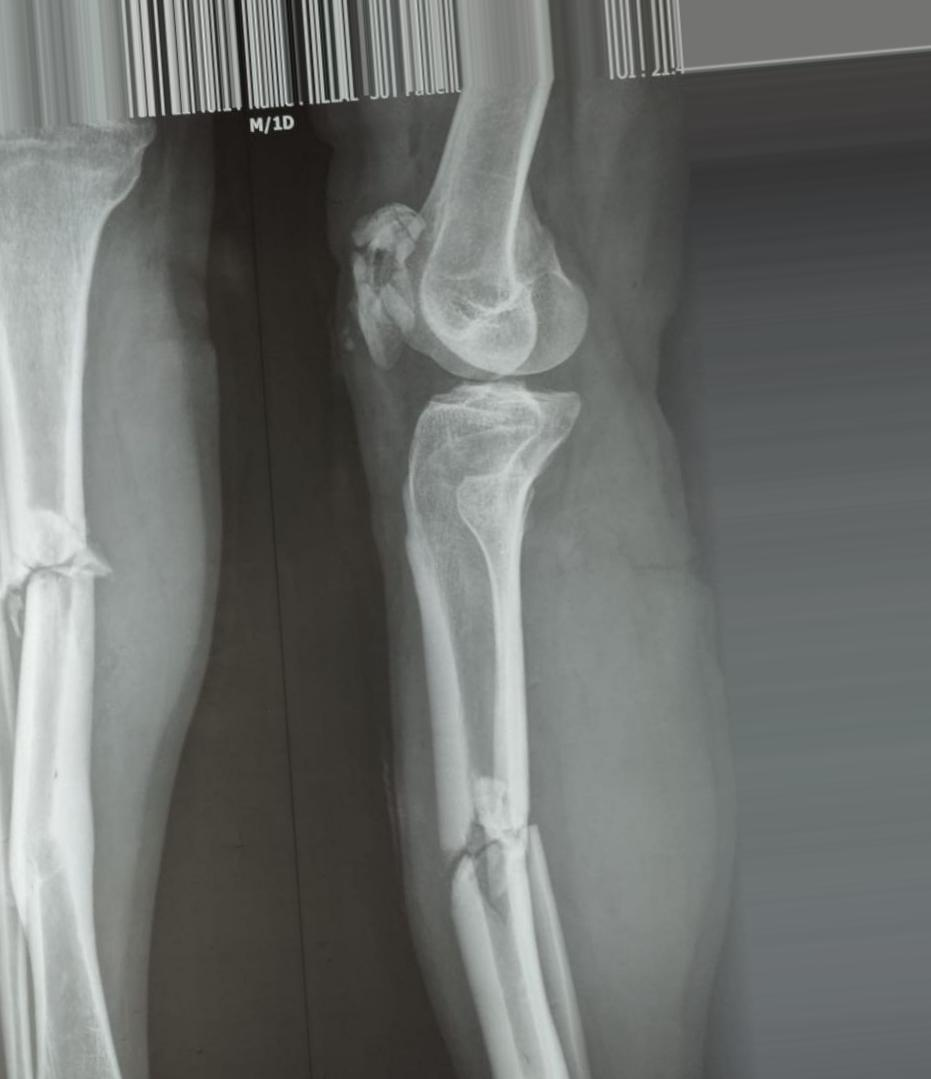

In [ ]:
data["train"][3]["image"]

In [ ]:
data["train"][3]["label"]

1

In [ ]:
data["train"].features["label"]

ClassLabel(names=['Comminuted Bone Fracture', 'Simple Bone Fracture'])

Class: Simple Bone Fracture


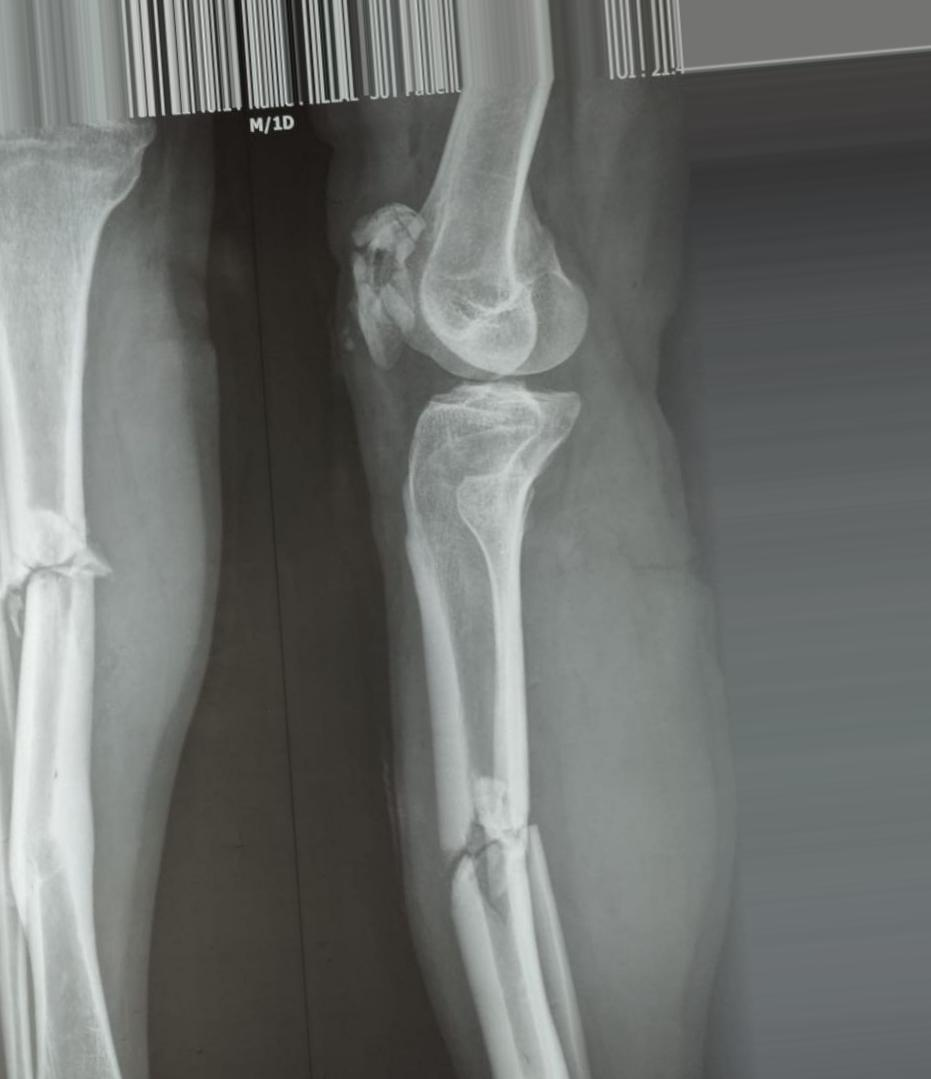

In [ ]:
sample = data["train"][3]

label_name = data["train"].features["label"].int2str(sample["label"])

print("Class:", label_name)

sample["image"]

In [ ]:
from typing import Any

FRACTURE_CLASSES = [
    "A: Comminuted Bone Fracture",
    "B: Simple Bone Fracture"
]

options = "\n".join(FRACTURE_CLASSES)
PROMPT = ("You are an expert orthopedic radiologist.\n\n"
          "Analyze the following X-ray image and identify the fracture type.\n\n"
    f"{options}\n\n"
    "Respond with only the correct option.")

def format_data(example: dict[str, Any]) -> dict[str, Any]:
    example["messages"] = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                },
                {
                    "type": "text",
                    "text": PROMPT,
                },
            ],
        },
        {
            "role": "assistant",
            "content": [
                {
                    "type": "text",
                    "text": FRACTURE_CLASSES[example["label"]],
                },
            ],
        },
    ]
    return example

In [ ]:
data = {key: dataset.map(format_data) for key, dataset in data.items()}

# Display a processed data sample
data["train"][3]

Map:   0%|          | 0/1668 [00:00<?, ? examples/s]

Map:   0%|          | 0/358 [00:00<?, ? examples/s]

Map:   0%|          | 0/358 [00:00<?, ? examples/s]

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=931x1079>,
 'label': 1,
 'messages': [{'role': 'user',
   'content': [{'type': 'image'},
    {'type': 'text',
     'text': 'You are an expert orthopedic radiologist.\n\nAnalyze the following X-ray image and identify the fracture type.\n\nA: Comminuted Bone Fracture\nB: Simple Bone Fracture\n\nRespond with only the correct option.'}]},
  {'role': 'assistant',
   'content': [{'type': 'text', 'text': 'B: Simple Bone Fracture'}]}]}

In [ ]:
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig

model_id = "google/medgemma-4b-it"

# Check if GPU supports bfloat16
if torch.cuda.get_device_capability()[0] < 8:
    raise ValueError("GPU does not support bfloat16, please use a GPU that supports bfloat16.")

model_kwargs = dict(
    attn_implementation="eager",
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

model_kwargs["quantization_config"] = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=model_kwargs["torch_dtype"],
    bnb_4bit_quant_storage=model_kwargs["torch_dtype"],
)

model = AutoModelForImageTextToText.from_pretrained(model_id, **model_kwargs)
processor = AutoProcessor.from_pretrained(model_id)

# Use right padding to avoid issues during training
processor.tokenizer.padding_side = "right"

config.json:   0%|          | 0.00/2.47k [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/90.6k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

...

preprocessor_config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

In [ ]:
from peft import LoraConfig

peft_config = LoraConfig(
    lora_alpha=16,
    lora_dropout=0.05,
    r=16,
    bias="none",
    target_modules="all-linear",
    task_type="CAUSAL_LM",
    modules_to_save=[
        "lm_head",
        "embed_tokens",
    ],
)

In [ ]:
from typing import Any


def collate_fn(examples: list[dict[str, Any]]):
    texts = []
    images = []
    for example in examples:
        images.append([example["image"].convert("RGB")])
        texts.append(processor.apply_chat_template(
            example["messages"], add_generation_prompt=False, tokenize=False
        ).strip())

    # Tokenize the texts and process the images
    batch = processor(text=texts, images=images, return_tensors="pt", padding=True)

    # The labels are the input_ids, with the padding and image tokens masked in
    # the loss computation
    labels = batch["input_ids"].clone()

    # Mask image tokens
    image_token_id = [
        processor.tokenizer.convert_tokens_to_ids(
            processor.tokenizer.special_tokens_map["boi_token"]
        )
    ]
    # Mask tokens that are not used in the loss computation
    labels[labels == processor.tokenizer.pad_token_id] = -100
    labels[labels == image_token_id] = -100
    labels[labels == 262144] = -100

    batch["labels"] = labels
    return batch

In [ ]:
from trl import SFTConfig

num_train_epochs = 5  # @param {type: "number"}
learning_rate = 2e-4  # @param {type: "number"}

args = SFTConfig(
    output_dir="medgemma-4b-it-bone-fracture-lora",            # Directory and Hub repository id to save the model to
    num_train_epochs=num_train_epochs,                       # Number of training epochs
    per_device_train_batch_size=4,                           # Batch size per device during training
    per_device_eval_batch_size=4,                            # Batch size per device during evaluation
    gradient_accumulation_steps=4,                           # Number of steps before performing a backward/update pass
    gradient_checkpointing=True,                             # Enable gradient checkpointing to reduce memory usage
    optim="adamw_torch_fused",                               # Use fused AdamW optimizer for better performance
    logging_steps=10,                                        # Number of steps between logs
    save_strategy="epoch",                                   # Save checkpoint every epoch
    eval_strategy="steps",                                   # Evaluate every `eval_steps`
    eval_steps=25,                                           # Number of steps between evaluations
    learning_rate=learning_rate,                             # Learning rate based on QLoRA paper
    bf16=True,                                               # Use bfloat16 precision
    max_grad_norm=0.3,                                       # Max gradient norm based on QLoRA paper
    warmup_ratio=0.03,                                       # Warmup ratio based on QLoRA paper
    lr_scheduler_type="linear",                              # Use linear learning rate scheduler
    push_to_hub=True,                                        # Push model to Hub
    report_to="tensorboard",                                 # Report metrics to tensorboard
    gradient_checkpointing_kwargs={"use_reentrant": False},  # Set gradient checkpointing to non-reentrant to avoid issues
    dataset_kwargs={"skip_prepare_dataset": True},           # Skip default dataset preparation to preprocess manually
    remove_unused_columns = False,                           # Columns are unused for training but needed for data collator
    label_names=["labels"],                                  # Input keys that correspond to the labels
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [ ]:
from trl import SFTTrainer

trainer = SFTTrainer(
    model=model,
    args=args,
    train_dataset=data["train"],
    eval_dataset=data["validation"],
    peft_config=peft_config,
    processing_class=processor,
    data_collator=collate_fn,
)

/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:1348: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)


In [ ]:

trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1, 'bos_token_id': 2, 'pad_token_id': 0}.
[transformers] Deprecated: `processor.image_token` will switch from returning `tokenizer.image_token` to `tokenizer.boi_token` in v5.11.


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
25,1.090813,0.094181,0.030932,128026.000000,0.974265
50,0.035981,0.035691,0.031352,256020.000000,0.975412
75,0.033627,0.031854,0.031560,383998.000000,0.979168
100,0.032086,0.032900,0.029778,512008.000000,0.978732
125,0.033029,0.030919,0.031775,636184.000000,0.979651
150,0.030803,0.031588,0.031003,764182.000000,0.979300
175,0.030807,0.030177,0.031111,892206.000000,0.979410
200,0.028290,0.029249,0.029126,1020188.000000,0.980834
225,0.026832,0.030293,0.029435,1144392.000000,0.979938
250,0.028321,0.028339,0.029702,1272406.000000,0.981048


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
25,1.090813,0.094181,0.030932,128026.000000,0.974265
50,0.035981,0.035691,0.031352,256020.000000,0.975412
75,0.033627,0.031854,0.031560,383998.000000,0.979168
100,0.032086,0.032900,0.029778,512008.000000,0.978732
125,0.033029,0.030919,0.031775,636184.000000,0.979651
150,0.030803,0.031588,0.031003,764182.000000,0.979300
175,0.030807,0.030177,0.031111,892206.000000,0.979410
200,0.028290,0.029249,0.029126,1020188.000000,0.980834
225,0.026832,0.030293,0.029435,1144392.000000,0.979938
250,0.028321,0.028339,0.029702,1272406.000000,0.981048


TrainOutput(global_step=525, training_loss=0.13551591843366623, metrics={'train_runtime': 13349.9866, 'train_samples_per_second': 0.625, 'train_steps_per_second': 0.039, 'total_flos': 6.958620305197018e+16, 'train_loss': 0.13551591843366623, 'epoch': 5.0})

In [ ]:
trainer.save_model()

No files have been modified since last commit. Skipping to prevent empty commit.


In [ ]:
from transformers import AutoModelForImageTextToText, AutoProcessor

# Ensure you have your HF_TOKEN set up if the model is private or to push updates

# The output_dir from your SFTConfig is the repository name on Hugging Face Hub
hf_repo_id = args.output_dir

# Load the fine-tuned model and processor from the Hugging Face Hub
# This will confirm if it was successfully pushed.
# Note: This might require `torch_dtype` and `device_map` if you intend to use it
# For simple confirmation, just loading the model architecture and processor might suffice

try:
    # Load processor
    loaded_processor = AutoProcessor.from_pretrained(hf_repo_id)
    print(f"Successfully loaded processor from {hf_repo_id}")

    # Load model (can be loaded with quantization config if needed for actual use)
    # For just confirming existence, we might not need all model_kwargs
    # If you want to load it fully, you might need to re-define model_kwargs
    loaded_model = AutoModelForImageTextToText.from_pretrained(hf_repo_id, torch_dtype=torch.bfloat16, device_map="auto")
    print(f"Successfully loaded model from {hf_repo_id}")

except Exception as e:
    print(f"Failed to load model from Hugging Face Hub: {e}")
    print("Please check your Hugging Face token permissions or if the repository exists.")



Successfully loaded processor from medgemma-4b-it-bone-fracture-lora


Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:1348: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)


Loading weights:   0%|          | 0/800 [00:00<?, ?it/s]

[transformers] Gemma3ForConditionalGeneration LOAD REPORT from: medgemma-4b-it-bone-fracture-lora
Key                                                              | Status     | 
-----------------------------------------------------------------+------------+-
model.language_model.embed_tokens.weight                         | UNEXPECTED | 
base_model.model.lm_head.weight                                  | UNEXPECTED | 
model.language_model.embed_tokens.modules_to_save.default.weight | MISSING    | 
lm_head.modules_to_save.default.weight                           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Successfully loaded model from medgemma-4b-it-bone-fracture-lora


In [ ]:
del model
del trainer
torch.cuda.empty_cache()

NameError: name 'model' is not defined

In [ ]:
from typing import Any

def format_test_data(example: dict[str, Any]) -> dict[str, Any]:
    example["messages"] = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                },
                {
                    "type": "text",
                    "text": PROMPT,
                },
            ],
        },
    ]
    return example

# Use the test split created earlier
test_data = data["test"]

# Format the dataset for inference
test_data = test_data.map(format_test_data)

Map:   0%|          | 0/358 [00:00<?, ? examples/s]

In [ ]:
import evaluate

accuracy_metric = evaluate.load("accuracy")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")
f1_metric = evaluate.load("f1")

REFERENCES = test_data["label"]

def compute_metrics(predictions):
    metrics = {}

    metrics.update(
        accuracy_metric.compute(
            predictions=predictions,
            references=REFERENCES,
        )
    )

    metrics.update(
        precision_metric.compute(
            predictions=predictions,
            references=REFERENCES,
            average="weighted",
        )
    )

    metrics.update(
        recall_metric.compute(
            predictions=predictions,
            references=REFERENCES,
            average="weighted",
        )
    )

    metrics.update(
        f1_metric.compute(
            predictions=predictions,
            references=REFERENCES,
            average="weighted",
        )
    )

    return metrics

In [ ]:
from datasets import ClassLabel

# Rename the class names to the fracture classes
test_data = test_data.cast_column(
    "label",
    ClassLabel(names=FRACTURE_CLASSES)
)

LABEL_FEATURE = test_data.features["label"]

# Mapping to alternative label format, e.g. (A) Comminuted Bone Fracture
ALT_LABELS = {
    label: f"({label.replace(': ', ') ')}"
    for label in FRACTURE_CLASSES
}


def postprocess(prediction: list[dict[str, str]], do_full_match: bool = False) -> int:
    response_text = prediction[0]["generated_text"].strip()

    if do_full_match:
        # Directly try to convert the response text if full match is expected
        try:
            return LABEL_FEATURE.str2int(response_text)
        except ValueError:
            # If it's not an exact match, try to match single characters 'A' or 'B'
            if response_text.upper() == 'A':
                return LABEL_FEATURE.str2int("A: Comminuted Bone Fracture")
            elif response_text.upper() == 'B':
                return LABEL_FEATURE.str2int("B: Simple Bone Fracture")
            return -1 # Return -1 if still no direct match

    # If do_full_match is False or direct match failed, try to find label substrings
    for label in FRACTURE_CLASSES:
        if label in response_text or ALT_LABELS[label] in response_text:
            return LABEL_FEATURE.str2int(label)

    # Additionally, check for single character 'A' or 'B' if not found above
    if response_text.upper() == 'A':
        return LABEL_FEATURE.str2int("A: Comminuted Bone Fracture")
    elif response_text.upper() == 'B':
        return LABEL_FEATURE.str2int("B: Simple Bone Fracture")

    return -1

Casting the dataset:   0%|          | 0/358 [00:00<?, ? examples/s]

In [ ]:
print(args.output_dir)


medgemma-4b-it-bone-fracture-lora


In [ ]:
from huggingface_hub import whoami

print(whoami())

{'type': 'user', 'id': '69a74c11ef702086cd229390', 'name': 'Herokie', 'fullname': 'ADERONKE ADELABU', 'email': 'c4063264@my.shu.ac.uk', 'emailVerified': True, 'canPay': False, 'billingMode': 'prepaid', 'periodEnd': 1785542400, 'isPro': False, 'avatarUrl': '/avatars/19a10c3e1d45b4e39310dae03610e8e2.svg', 'orgs': [], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'HF_TOKEN', 'role': 'write', 'createdAt': '2026-07-08T09:45:46.523Z'}}}


In [ ]:
from transformers import AutoModelForImageTextToText, AutoProcessor
import torch

repo_id = "Herokie/medgemma-4b-it-bone-fracture-lora"

processor = AutoProcessor.from_pretrained(repo_id)

model = AutoModelForImageTextToText.from_pretrained(
    repo_id,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

processor_config.json:   0%|          | 0.00/519 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/745 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

adapter_config.json:   0%|          | 0.00/1.17k [00:00<?, ?B/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:1348: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)


adapter_model.safetensors:   0%|          | 0.00/2.76G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/800 [00:00<?, ?it/s]

[transformers] Gemma3ForConditionalGeneration LOAD REPORT from: Herokie/medgemma-4b-it-bone-fracture-lora
Key                                                              | Status     | 
-----------------------------------------------------------------+------------+-
model.language_model.embed_tokens.weight                         | UNEXPECTED | 
base_model.model.lm_head.weight                                  | UNEXPECTED | 
model.language_model.embed_tokens.modules_to_save.default.weight | MISSING    | 
lm_head.modules_to_save.default.weight                           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import pipeline

pt_pipe = pipeline(
    "image-text-to-text",
    model=model,
    processor=processor,
    torch_dtype=torch.bfloat16,
)

pt_pipe.model.generation_config.do_sample = False
pt_pipe.model.generation_config.pad_token_id = processor.tokenizer.eos_token_id

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


In [ ]:
import copy

formatted_test_messages = []

for i in range(len(test_data)):
    current_messages = test_data[i]["messages"]
    current_image = test_data[i]["image"]

    message_with_image = copy.deepcopy(current_messages)

    for content_item in message_with_image[0]["content"]:
        if content_item.get("type") == "image":
            content_item["image"] = current_image
            break

    formatted_test_messages.append(message_with_image)

pt_outputs = pt_pipe(
    text=formatted_test_messages,
    max_new_tokens=15,      # Short answers only
    batch_size=64,
    return_full_text=False,
)

pt_predictions = [postprocess(out) for out in pt_outputs]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'return_dict_in_generate'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=15) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=15) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=15) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. 

In [ ]:
pt_metrics = compute_metrics(pt_predictions)
print(f"Baseline metrics: {pt_metrics}")

Baseline metrics: {'accuracy': 0.8631284916201117, 'precision': 0.8988349342211481, 'recall': 0.8631284916201117, 'f1': 0.8785174295461667}


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from transformers import pipeline

ft_pipe = pipeline(
    "image-text-to-text",
    model=model,
    processor=processor,
    torch_dtype=torch.bfloat16,
)

ft_pipe.model.generation_config.do_sample = False
ft_pipe.model.generation_config.pad_token_id = processor.tokenizer.eos_token_id

ft_outputs = ft_pipe(
    text=formatted_test_messages,
    max_new_tokens=20,
    batch_size=64,
    return_full_text=False,
)

ft_predictions = [postprocess(out, do_full_match=False) for out in ft_outputs]

[transformers] Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

In [ ]:
ft_metrics = compute_metrics(ft_predictions)
print(f"Fine-tuned metrics: {ft_metrics}")

Fine-tuned metrics: {'accuracy': 0.8659217877094972, 'precision': 0.8991847834879116, 'recall': 0.8659217877094972, 'f1': 0.8800231128591771}


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
